# Cartoonifying Images and Videos

This notebook demonstrates a basic yet effective cartoonification process using classical computer vision techniques with OpenCV. The goal is to transform normal photographs and video frames into cartoon-style visuals by applying a sequence of filtering and edge-detection operations. The project is structured to handle **images**, **video files**, and **live webcam streams**.


# Requirements

The following libraries are required:

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time
import sys
import os

# Cartoonify Function



## Algorithm Explanation

The `cartoonify()` function processes an input image using the following pipeline:

1. **Grayscale Conversion:**  
   Convert the original color image to a grayscale image using `cv2.cvtColor`. This simplifies the information and reduces computation.

2. **Smoothing:**  
   Apply a median blur (`cv2.medianBlur`) to the grayscale image to reduce noise while preserving edges.

3. **Edge Detection:**  
   Use `cv2.adaptiveThreshold` to extract prominent edges in the image, producing a binary edge mask.
   - Input: The smoothed grayscale image (smoothGrayScale).
   - Parameters:
     - Maximum pixel intensity (255)
     - Adaptive thresholding method (cv2.ADAPTIVE_THRESH_GAUSSIAN_C)
     - Threshold type (cv2.THRESH_BINARY)
     - Block size (5)
     - Constant subtracted (3)
     
4. **Color Smoothing:**  
   A bilateral filter (`cv2.bilateralFilter`) is applied to the original image to smooth color regions while preserving edges. This helps simulate the flat colors typical of cartoons. 
   - Input: The original color image (image).
   - Parameters:
     - Diameter of pixel neighborhood (9)
     - Sigma values for color and space (300, 300)

5. **Combining Edges and Colors:**  
   The result is produced by masking the color-smoothed image with the edge mask using `cv2.bitwise_and`, which preserves only the areas within the edges.

In [8]:
def cartoonify(image):
    if image is None:
        raise ValueError("Image not loaded correctly.")
    grayScaleImage = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    smoothGrayScale = cv2.medianBlur(grayScaleImage, 5)
    getEdge = cv2.adaptiveThreshold(
        smoothGrayScale, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY, 5, 3
        # cv2.ADAPTIVE_THRESH_MEAN_C,
        # cv2.THRESH_BINARY, 9, 9
    )
    colorImage = cv2.bilateralFilter(image, 9, 300, 300)
    cartoonImage = cv2.bitwise_and(colorImage, colorImage, mask=getEdge)
    return cartoonImage

# Cartoonifying Images

This section reads all image files in the images/ folder, applies the cartoonify() function, and displays both original and cartoonified versions side by side using matplotlib.

- Input: Any standard image (.jpg, .jpeg, .png, .bmp)
- Output: Cartoonified version displayed alongside original

Processing Einstein.jpeg...


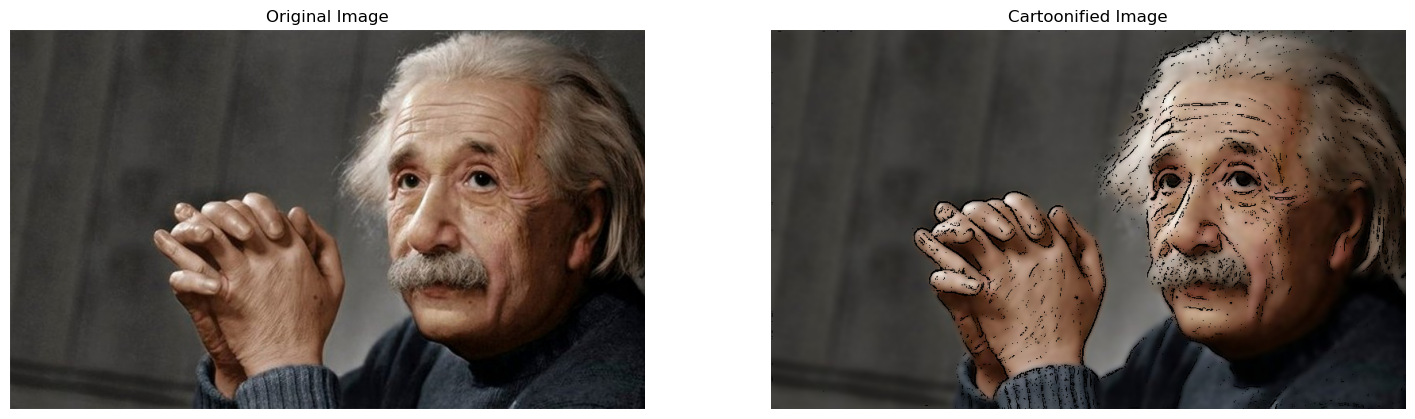

Processing elk.jpg...


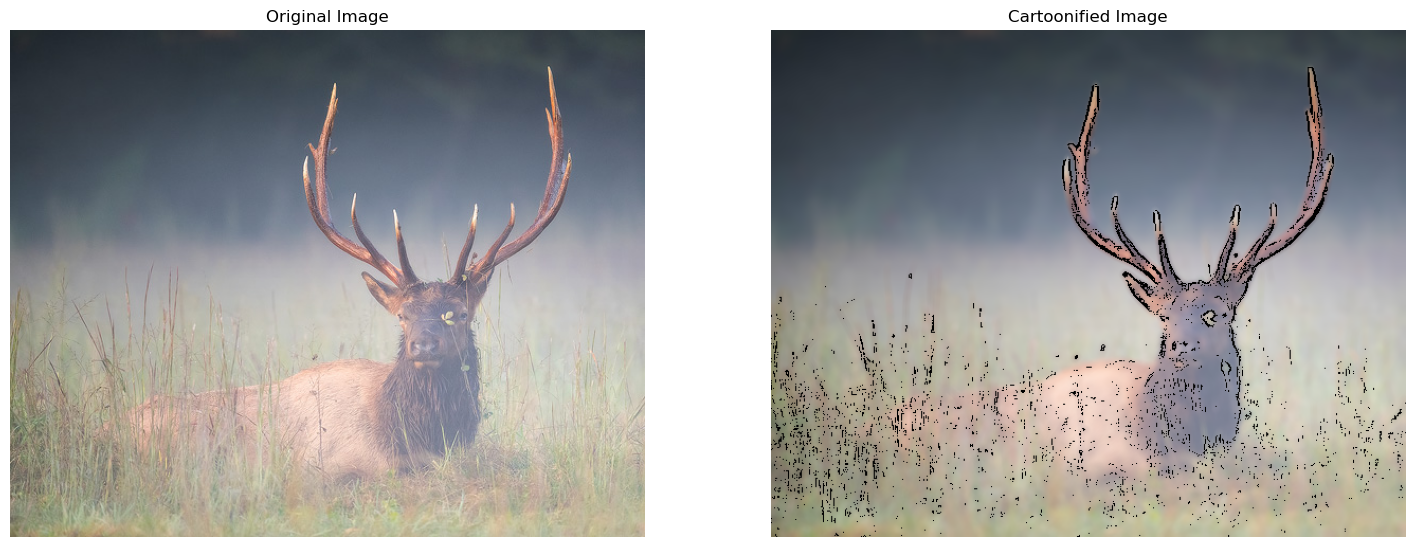

Processing heron.jpg...


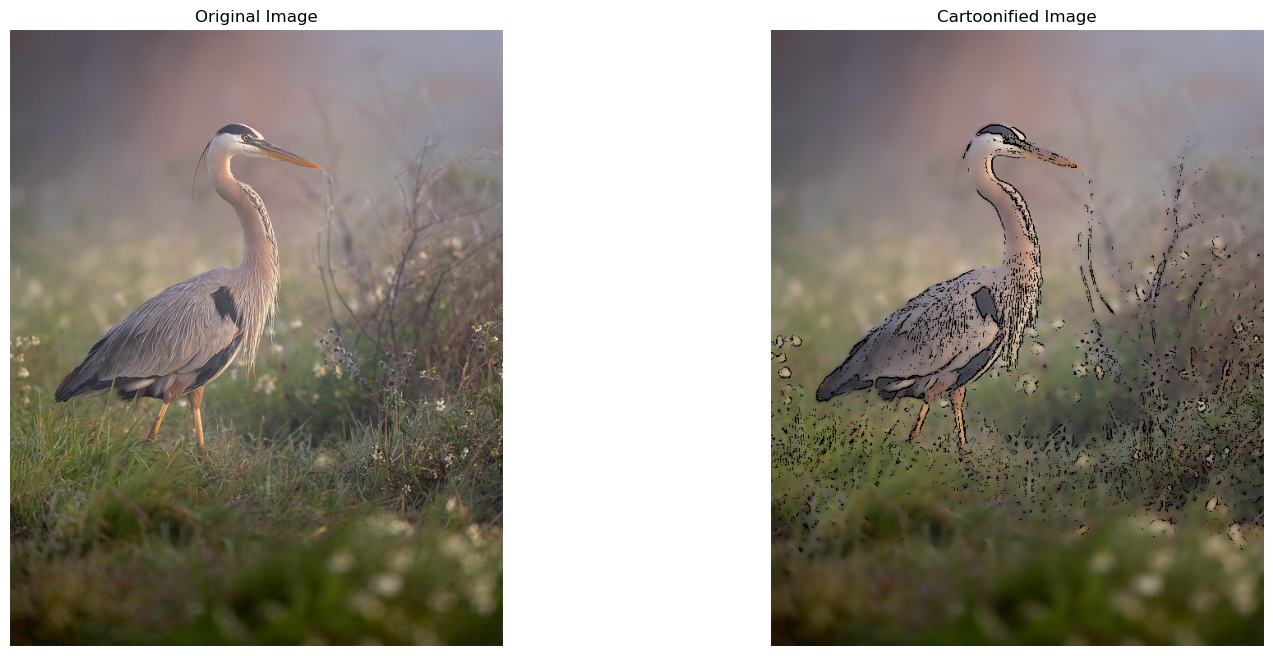

Processing sunny.jpg...


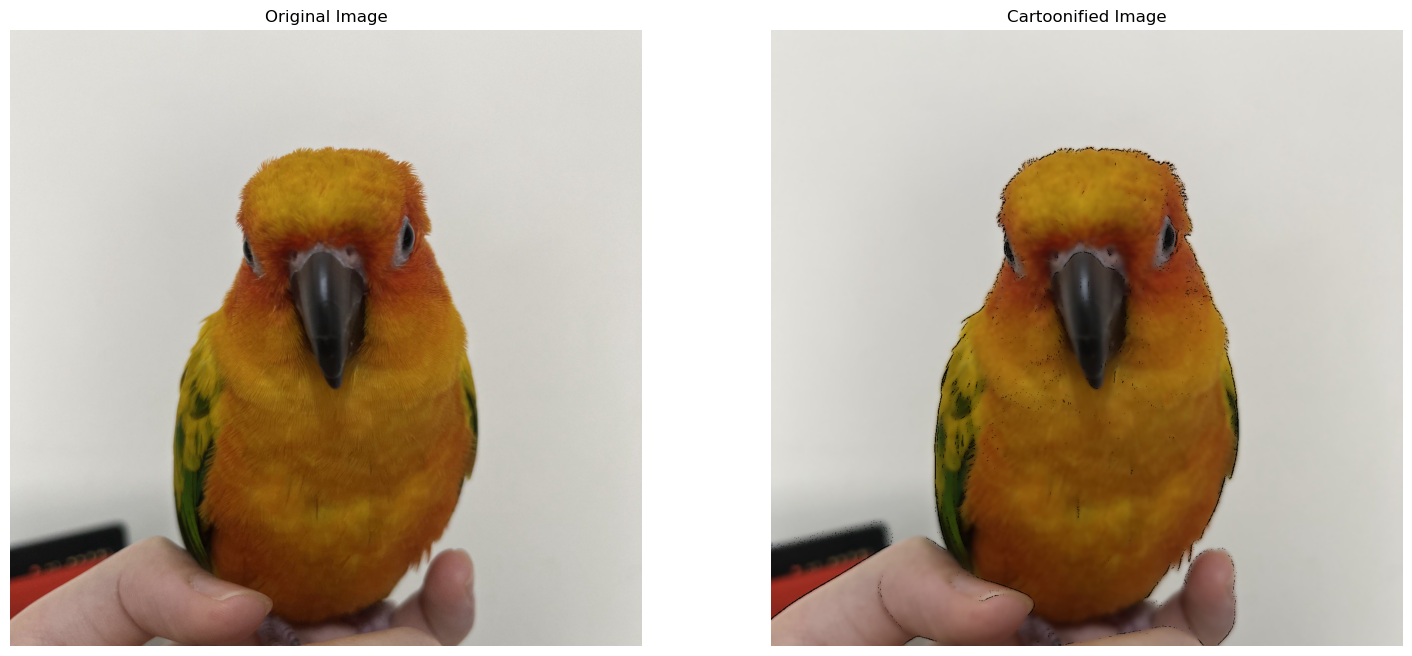

In [9]:
IMAGES_DIR = "images"
OUTPUT_DIR = "./output"
os.makedirs(OUTPUT_DIR, exist_ok=True) 

for filename in os.listdir(IMAGES_DIR):
    if filename.lower().endswith((".jpeg", ".jpg", ".png", ".bmp")):
        image_path = os.path.join(IMAGES_DIR, filename)
        print(f"Processing {filename}...")
        image = cv2.imread(image_path)
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        result = cartoonify(image)

        # Save output image
        output_path = os.path.join(OUTPUT_DIR, f"cartoon_{filename}")
        cv2.imwrite(output_path, result)

        # Optionally visualize
        result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(18, 8))
        plt.subplot(1, 2, 1)
        plt.title("Original Image")
        plt.imshow(image_rgb)
        plt.axis("off")
        plt.subplot(1, 2, 2)
        plt.title("Cartoonified Image")
        plt.imshow(result_rgb)
        plt.axis("off")
        plt.show()

# Cartoonify Webcam Video Stream

This section continuously captures frames from the webcam, cartoonifies them in real-time, and overlays the frame rate (FPS).

In [10]:
def visualize_fps(image, fps: int):
    # Check if the image is grayscale or colored.
    # If it's grayscale, set the text color to white; if colored, set the text color to green.
    if len(np.shape(image)) < 3:
        text_color = (255, 255, 255)  # White color for grayscale images.
    else:
        text_color = (0, 255, 0)  # Green color for colored images.

    # Define the row size for the text placement.
    row_size = 20 
    # Define the left margin for the text placement.
    left_margin = 24 

    # Set the font size and thickness for the text.
    font_size = 1
    font_thickness = 2

    # Format the FPS value into a string for displaying.
    fps_text = "FPS = {:.1f}".format(fps)
    # Set the text location on the image.
    text_location = (left_margin, row_size)
    
    # Place the FPS text on the image.
    cv2.putText(
        image,
        fps_text,
        text_location,
        cv2.FONT_HERSHEY_PLAIN,
        font_size,
        text_color,
        font_thickness,
    )

    # Return the modified image with the FPS text.
    return image


In [11]:
# === Webcam Mode ===

# Constants for camera settings
CAMERA_DEVICE_ID = 0  # ID for the camera device
IMAGE_WIDTH = 800  # Width of the captured image
IMAGE_HEIGHT = 600  # Height of the captured image
fps = 0  # Initial Frames Per Second (FPS) value

if __name__ == "__main__":
    try:
        cap = cv2.VideoCapture(CAMERA_DEVICE_ID)

        while True:
            start_time = time.time()

            ret, frame = cap.read()
            if not ret:
                break

            frame = cv2.resize(frame, (IMAGE_WIDTH, IMAGE_HEIGHT))
            cartoon_frame = cartoonify(frame)

            cv2.imshow("frame", visualize_fps(cartoon_frame, fps))

            end_time = time.time()
            seconds = end_time - start_time
            fps = 1 / seconds if seconds != 0 else 0

            if cv2.waitKey(33) == 27:
                break
    except Exception as e:
        print(e)
    finally:
        cv2.destroyAllWindows()
        cap.release()

# Cartoonifying Videos

This section processes all .mp4 videos in the videos/ folder. For each frame, it applies cartoonification and shows real-time results with FPS overlay.

In [12]:
# === Video Mode ===

VIDEOS_DIR = "videos"
IMAGE_WIDTH = 1000
IMAGE_HEIGHT = 600
FRAME_RATE = 30
DURATION = 1 / FRAME_RATE

for filename in os.listdir(VIDEOS_DIR):
    if filename.endswith(".mp4"):
        video_path = os.path.join(VIDEOS_DIR, filename)
        print(f"Processing {filename}...")

        output_video_path = os.path.join(OUTPUT_DIR, f"cartoon_{filename}")
        cap = cv2.VideoCapture(video_path)
        fourcc = cv2.VideoWriter_fourcc(*"mp4v")
        out = cv2.VideoWriter(output_video_path, fourcc, FRAME_RATE, (IMAGE_WIDTH, IMAGE_HEIGHT))

        try:
            while True:
                start_time = time.time()
                ret, frame = cap.read()
                if not ret:
                    break
                frame = cv2.resize(frame, (IMAGE_WIDTH, IMAGE_HEIGHT))
                cartoon_frame = cartoonify(frame)
                cartoon_frame = visualize_fps(cartoon_frame, fps)
                out.write(cartoon_frame)  # Save cartoonified frame

                # Optional live view
                cv2.imshow("frame", cartoon_frame)

                elapsed = time.time() - start_time
                fps = 1 / elapsed if elapsed != 0 else 0
                if elapsed < DURATION:
                    time.sleep(DURATION - elapsed)
                if cv2.waitKey(33) == 27:
                    break
        except Exception as e:
            print(e)
        finally:
            cap.release()
            out.release()
            cv2.destroyAllWindows()


Processing Einstein_1.mp4...
Processing Einstein_2.mp4...
Processing Jobs_1.mp4...
Processing Jobs_2.mp4...
